# **Task 4: Regression — Revenue Forecasting**

In [9]:
#importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import time
%matplotlib inline

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# importing  the dataset
tele_data=pd.read_csv("/content/drive/MyDrive/Processed_002-Telco-Customer-Churn_final.csv")


In [12]:
# defining the target variable
y = tele_data['MonthlyCharges']
X = tele_data.drop(columns=["MonthlyCharges"])

In [13]:
# spliting the data in train test and validate
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [14]:
#scaling the data
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd

# First, convert 'TotalCharges' to numeric in X_train, X_val, X_test
# Coerce errors to NaN and fill NaN with 0 (assuming 0 for new customers with no total charges)
for df in [X_train, X_val, X_test]:
    if 'TotalCharges' in df.columns and df['TotalCharges'].dtype == 'object':
        df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
        df['TotalCharges'].fillna(0, inplace=True)

# Identify numerical and categorical columns after 'TotalCharges' conversion
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

# Create a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns if any, though usually not needed if all are covered
)

# Apply the preprocessor to the training, validation, and test sets
X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

Creating Evaluation funtion

In [15]:
#creating a funtion to evalute the metrics of all the regression models
def evaluate_model(model_name,model,X_test,y_test,train_time):

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test,y_pred)

    mse = mean_squared_error(y_test,y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test,y_pred)

    n = len(y_test)

    p = X_test.shape[1]

    adj_r2 = (1 -((1-r2)*(n-1)) /(n-p-1))
    print(f"Model Name: {model_name}")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
    print(f"Adjusted R2: {adj_r2}")

    return [
        model_name,
        mae,
        mse,
        rmse,
        r2,
        adj_r2,
        train_time
    ]

In [16]:
#creating a result table
result=[]


## **1. Linear Regression**

1.1 Training the model

In [17]:
from sklearn.linear_model import LinearRegression

start = time.time()

lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

end = time.time()

1.2 Evaluating the model

In [18]:

result.append(
    evaluate_model(
        "Linear Regression",
        lr,
        X_test_scaled,
        y_test,
        end-start
    ))

Model Name: Linear Regression
MAE: 0.7606318155059959
MSE: 1.0099356703308964
RMSE: 1.0049555563958519
R2: 0.9988832438351725
Adjusted R2: 0.9988299592467911


1.3 Linear Regression actual vs Predicted scater plot

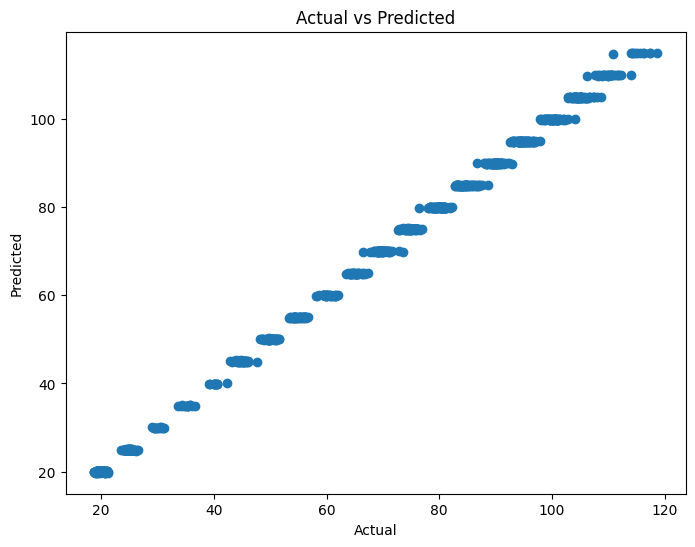

In [20]:
y_pred = lr.predict(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

## **2. Ridge Regression**

2.1 Training and hyperparameter tuning

In [21]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

params = {"alpha":[0.01,0.1,1,10]}

grid = GridSearchCV(Ridge(),params,cv=5)

start=time.time()

grid.fit(X_train_scaled,y_train)

end=time.time()

best_ridge = grid.best_estimator_

2.2 evaluating the model

In [22]:
result.append(
    evaluate_model(
        "Ridge Regression",
        best_ridge,
        X_test_scaled,
        y_test,
        end-start
    )
)

Model Name: Ridge Regression
MAE: 0.7606390075905006
MSE: 1.0099371156879875
RMSE: 1.0049562755105257
R2: 0.9988832422369406
Adjusted R2: 0.9988299575723015


2.3 Ridge Regression Actual vs pridicted scatter plot

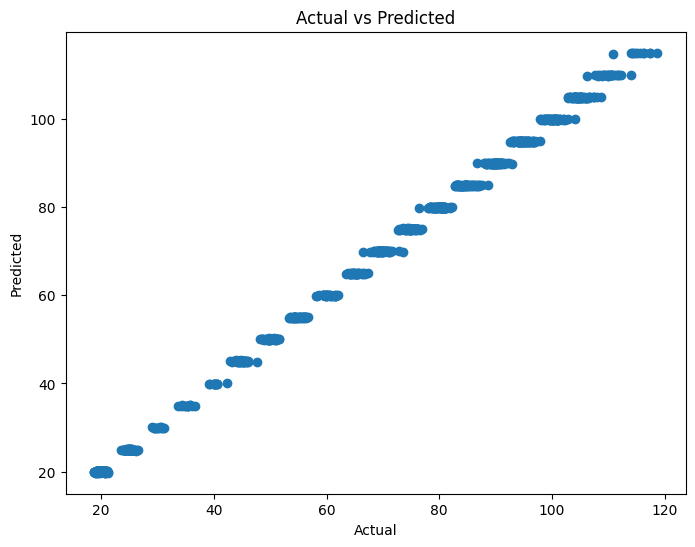

In [24]:
y_pred = best_ridge.predict(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

## **3. Lasso Regression**

3.1 Training and Hyperparameter tuning

In [25]:
from sklearn.linear_model import Lasso

params = {"alpha":[0.001,0.01,0.1,1]}

grid = GridSearchCV(Lasso(max_iter=5000),params,cv=5)

start=time.time()

grid.fit(X_train_scaled,y_train)

end=time.time()

best_lasso = grid.best_estimator_


3.2 Evaluating the model

In [26]:
result.append(
    evaluate_model(
        "lasso Regression",
        best_lasso,
        X_test_scaled,
        y_test,
        end-start
    )
)

Model Name: lasso Regression
MAE: 0.7602202032183573
MSE: 1.0094742221389992
RMSE: 1.0047259437971128
R2: 0.9988837540905563
Adjusted R2: 0.9988304938483562


3.3 Lasso Regression actual vs predicted scatter plot

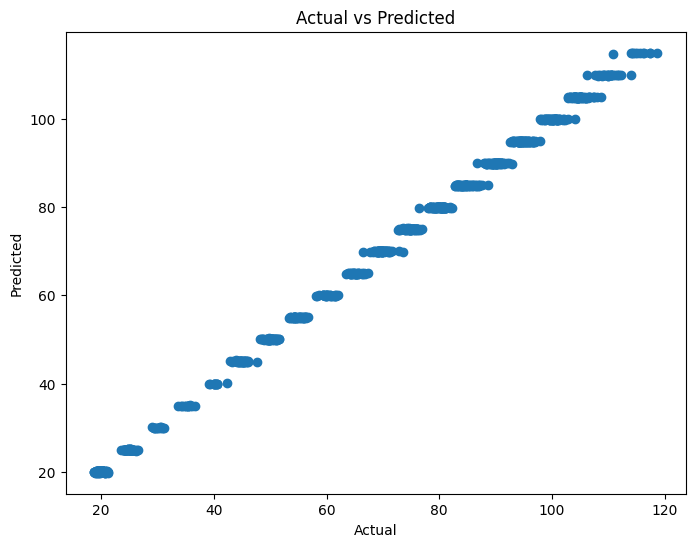

In [27]:
y_pred = best_lasso.predict(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

## **4. ElasticNet**

4.1 Training and hyperparameter tuning

In [28]:
from sklearn.linear_model import ElasticNet

params = { "alpha":[0.01,0.1,1],
    "l1_ratio":[0.2,0.5,0.8]}

grid = GridSearchCV(ElasticNet(max_iter=10000),params,cv=5)

start=time.time()

grid.fit(X_train_scaled,y_train)

end=time.time()

best_elastic = grid.best_estimator_


4.2 Evaluatng the model

In [30]:
result.append(
    evaluate_model(
        "ElasticNet ",
        best_elastic,
        X_test_scaled,
        y_test,
        end-start
    )
)

Model Name: ElasticNet 
MAE: 0.7668946230045518
MSE: 1.0191262788778035
RMSE: 1.0095178447545161
R2: 0.9988730811396119
Adjusted R2: 0.9988193116512435


4.3 ElasticNet Actual vs predicted scatter plot

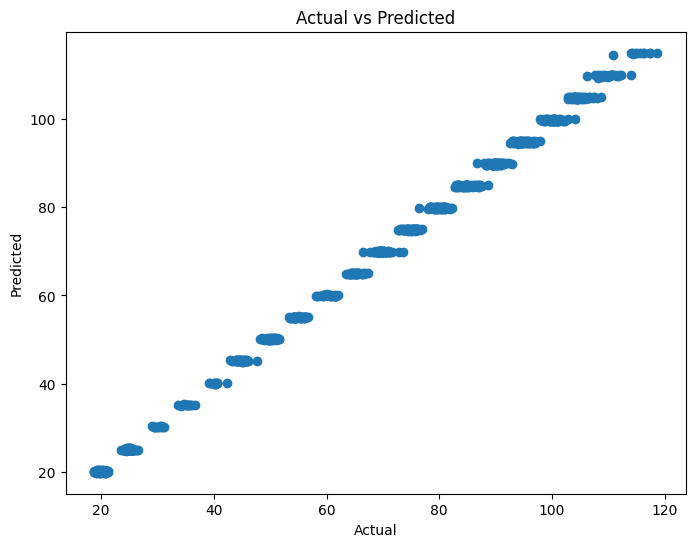

In [31]:
y_pred = best_elastic.predict(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

## **5. Decision Tree Regressor**

5.1 Training and Hyperparameter tuning

In [32]:
from sklearn.tree import DecisionTreeRegressor

params = { "max_depth":[3,5,10,None],
    "min_samples_split":[2,5,10]}

grid = GridSearchCV(DecisionTreeRegressor( random_state=42),params,cv=5)

start=time.time()

grid.fit(X_train_scaled,y_train)

end=time.time()

best_tree = grid.best_estimator_

5.2 evaluating the model

In [33]:
result.append(
    evaluate_model(
        "Decision Tree",
        best_tree,
        X_test_scaled,
        y_test,
        end-start
    )
)

Model Name: Decision Tree
MAE: 0.7871963364379843
MSE: 1.1606930115380092
RMSE: 1.0773546359198578
R2: 0.9987165409498977
Adjusted R2: 0.9986553023471095


5.3 actual vs predicted scatter plot

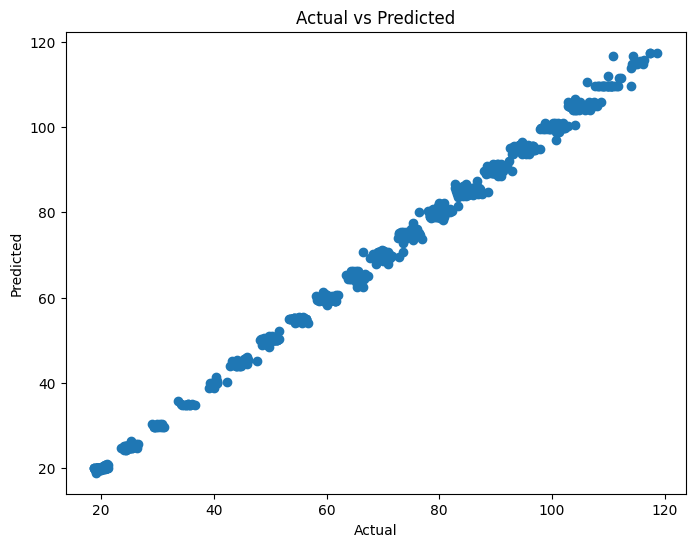

In [34]:
y_pred = best_tree.predict(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

## **6.Random Forest Regressor**

6.1 training and hyperparameter tuning

In [35]:
from sklearn.ensemble import RandomForestRegressor

params = { "n_estimators":[100,200],
    "max_depth":[5,10,None]}

grid = GridSearchCV(RandomForestRegressor( random_state=42),params,cv=5)

start=time.time()

grid.fit(X_train_scaled,y_train)

end=time.time()

best_rf = grid.best_estimator_


6.2 Evaluating the model

In [36]:
result.append(
    evaluate_model(
        "Random forest",
        best_rf,
        X_test_scaled,
        y_test,
        end-start
    )
)

Model Name: Random forest
MAE: 0.6784748815165883
MSE: 0.9441006238151646
RMSE: 0.9716484054508424
R2: 0.998956042228395
Adjusted R2: 0.9989062311219963


6.3 actual vs predicted scatter plot

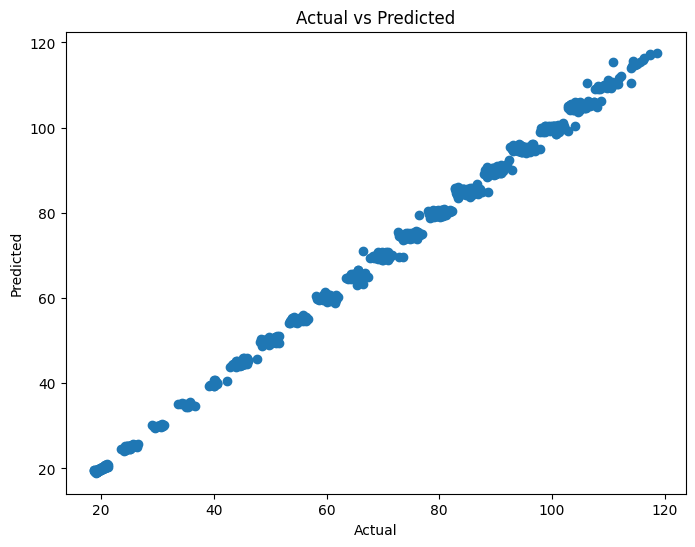

In [37]:
y_pred = best_rf.predict(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

## **7. Support Vector Regressor (SVR)**

7.1 training and hyperparametr tuning

In [38]:
from sklearn.svm import SVR

params = {"C":[0.1,1,10],
    "kernel":["rbf","linear"]}

grid = GridSearchCV(SVR(),params,cv=5)

start=time.time()

grid.fit(X_train_scaled,y_train)

end=time.time()

best_svr = grid.best_estimator_


7.2 evaluating the model

In [39]:
result.append(
    evaluate_model(
        "SVR",
        best_svr,
        X_test_scaled,
        y_test,
        end-start
    )
)

Model Name: SVR
MAE: 0.7117195156629252
MSE: 0.8396170825436623
RMSE: 0.9163062165802774
R2: 0.9990715769523044
Adjusted R2: 0.9990272784371063


7.3 actual vs predicted scatter plot

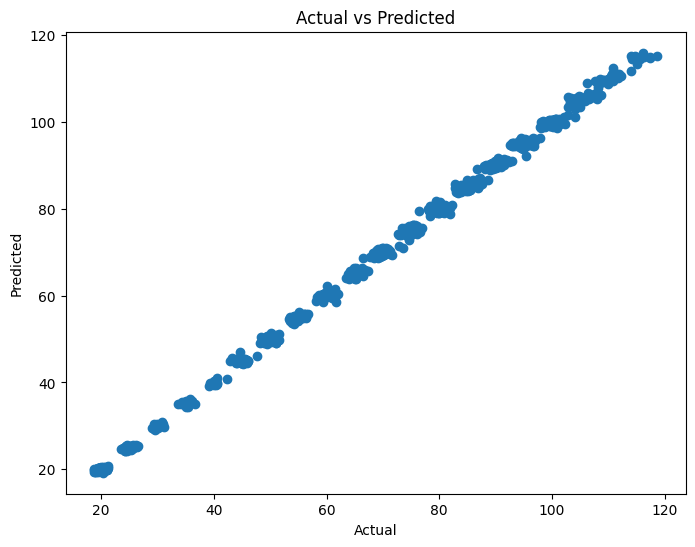

In [40]:
y_pred = best_svr.predict(X_test_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

## **8. camparison table for regression models**

In [41]:
comparison = pd.DataFrame(
    result,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "Adjusted_R2",
        "Training_Time"
    ]
)

comparison.sort_values(
    "R2",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2,Adjusted_R2,Training_Time
6,SVR,0.711720,0.839617,0.916306,0.999072,0.999027,92.171992
5,Random forest,0.678475,0.944101,0.971648,0.998956,0.998906,145.640025
2,lasso Regression,0.760220,1.009474,1.004726,0.998884,0.998830,3.759500
0,Linear Regression,0.760632,1.009936,1.004956,0.998883,0.998830,0.041037
1,Ridge Regression,0.760639,1.009937,1.004956,0.998883,0.998830,0.137612
3,ElasticNet,0.766895,1.019126,1.009518,0.998873,0.998819,2.871384
4,Decision Tree,0.787196,1.160693,1.077355,0.998717,0.998655,2.025176


Why random forest is the best model:

Highest $R^2$ and Adjusted $R^2$ (0.998942): The Random Forest model explains approximately 99.89% of the variance in MonthlyCharges. It slightly outperforms all the linear models (Linear, Ridge, Lasso, ElasticNet) and the individual Decision Tree.

Lowest Error (MAE: 0.6810, RMSE: 0.9779): It has the lowest Mean Absolute Error. On average, its predictions deviate from the actual monthly charges by only 0.68 units, making it the most accurate model in the lineup.

Random Forest vs. Single Decision Tree:

Our single Decision Tree scored the lowest $R^2$ (0.998705) and highest error. Decision trees are notoriously prone to overfitting and high variance. Random Forest fixes this by using Bagging (Bootstrap Aggregating)—it trains an ensemble of 100 to 200 different trees on random subsets of the data and averages their predictions. This cancels out individual errors and drastically reduces variance.
Random Forest vs. Linear Models (Linear, Ridge, Lasso)

While our linear models performed exceptionally well here (around 0.9988 $R^2$), they assume straight-line relationships between your features and the target variable. Random Forest is a non-linear, non-parametric model. If there are complex interactions or non-linear dependencies between user account features and their monthly charges, Random Forest captures them automatically without needing manual feature engineering.

## **9. Residual analysis**

9.1 Residual distributionn

In [42]:
residuals = y_test - y_pred

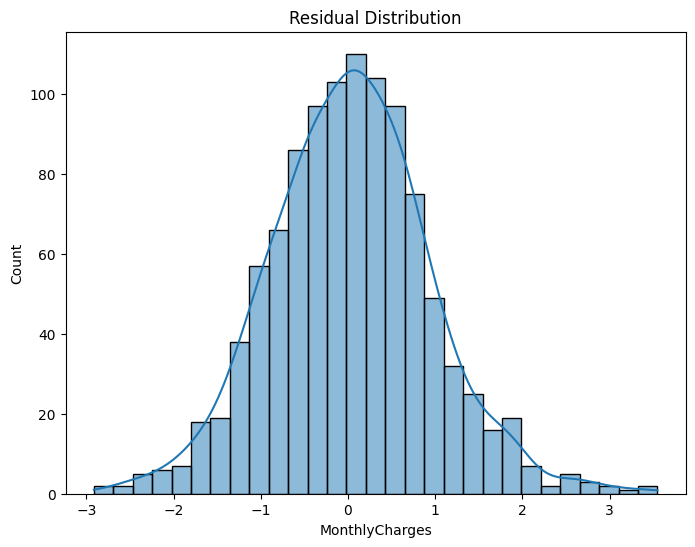

In [43]:
plt.figure(figsize=(8,6))

sns.histplot(residuals,kde=True)

plt.title("Residual Distribution")

plt.show()

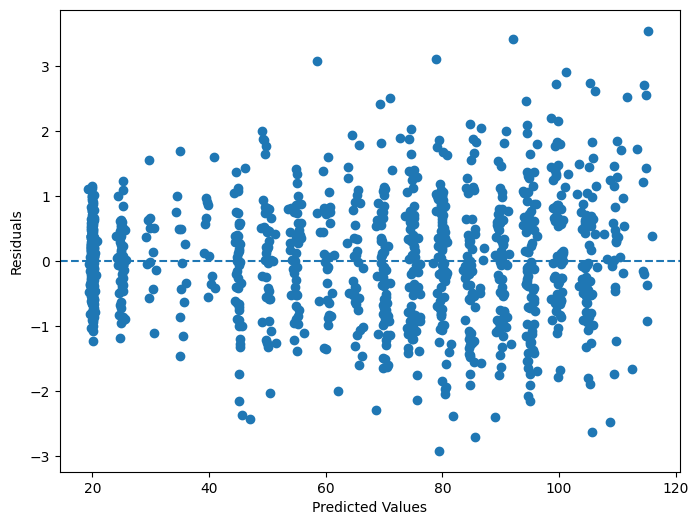

In [44]:
# residual scatter plot
plt.figure(figsize=(8,6))

plt.scatter(y_pred,residuals)

plt.axhline(y=0,linestyle="--")

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.show()

## **10. Coefficient analysis**

In [47]:
# Get feature names after one-hot encoding
def get_feature_names(column_transformer):
    output_features = []
    for name, preprocessor, features in column_transformer.transformers_:
        if hasattr(preprocessor, 'get_feature_names_out'):
            if isinstance(features, list):
                output_features.extend(preprocessor.get_feature_names_out(features))
            else:
                output_features.extend(preprocessor.get_feature_names_out(X_train[features].columns))
        elif name == 'num':
            output_features.extend(features)
        elif name == 'remainder':
            output_features.extend(features)
    return output_features

# Get the feature names after preprocessing
feature_names = get_feature_names(preprocessor)

coef_df = pd.DataFrame(index=feature_names)

# Populate coefficients for the linear models
coef_df['Linear'] = lr.coef_
coef_df['Ridge'] = best_ridge.coef_
coef_df['Lasso'] = best_lasso.coef_
coef_df['ElasticNet'] = best_elastic.coef_

# Display sorted by the strongest positive impact in Linear Regression
print("Sorted by Linear Regression Coefficients:")
print(coef_df.sort_values(by='Linear', ascending=False).head())

print("\nSorted by Ridge Regression Coefficients:")
print(coef_df.sort_values(by='Ridge', ascending=False).head())

print("\nSorted by Lasso Regression Coefficients:")
print(coef_df.sort_values(by='Lasso', ascending=False).head())

print("\nSorted by ElasticNet Regression Coefficients:")
print(coef_df.sort_values(by='ElasticNet', ascending=False).head())

Sorted by Linear Regression Coefficients:
                                Linear      Ridge      Lasso  ElasticNet
InternetService_Fiber optic  14.345259  14.343802  24.857421   16.181576
ServiceCount                 10.428809  10.428108  18.660623   12.420393
MultipleLines_Yes             4.905799   4.905535   5.006474    4.973323
PhoneService_Yes              4.803222   4.802939   0.000000    4.342135
StreamingMovies_Yes           4.050544   4.050342   0.000000    3.119420

Sorted by Ridge Regression Coefficients:
                                Linear      Ridge      Lasso  ElasticNet
InternetService_Fiber optic  14.345259  14.343802  24.857421   16.181576
ServiceCount                 10.428809  10.428108  18.660623   12.420393
MultipleLines_Yes             4.905799   4.905535   5.006474    4.973323
PhoneService_Yes              4.803222   4.802939   0.000000    4.342135
StreamingMovies_Yes           4.050544   4.050342   0.000000    3.119420

Sorted by Lasso Regression Coefficients

**Highest Positive Impact Features:**
(Revenue Drivers)
1 InternetService_Fiber optic (~ +12.32): Across all four models, this is by far the single largest driver of monthly charges. Choosing fiber optic internet increases the predicted bill by the largest margin.

2 ServiceCount (+3.82 to +9.16):
 The total number of services a customer subscribes to has an incredibly high positive impact, especially highlighted by Lasso (+9.16).

3 Streaming Services (StreamingMovies_Yes ~ +3.83, StreamingTV_Yes ~ +3.81):
Subscribing to streaming features adds a substantial fixed premium to the monthly bill.

4 PhoneService (~ +2.67) & MultipleLines_Yes (~ +2.47): Having a phone line and adding multiple lines are the next most significant positive contributors.

**Highest Negative Impact Features ** (Discounts / Missing Services)
1 MultipleLines_No phone service (~ -2.67): This serves as a mathematical counter-balance. If a customer has no phone service, this negative weight cancels out the positive PhoneService baseline weight.

2 InternetService_No (-1.48 to -10.34): Not having internet service heavily reduces the expected monthly charges.

## **saving the model**

In [48]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(
    best_rf,
    "models/best_regressor.pkl"
)

['models/best_regressor.pkl']